In [73]:
# Watershed: https://plantcv.org/tutorials/watershed

In [74]:
# Import libraries
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs

# Print out the version of PlantCV being used by the Jupyter kernel
pcv.__version__

'4.10.2'

In [75]:
# Input/output options
args = WorkflowInputs(
    images=["./../GeminiConteo4.jpg"],
    names="image1",
    result="segmentation_results.json",
    outdir=".",
    writeimg=False,
    debug="plot"
    )

In [76]:
# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 100
pcv.params.text_size = 20
pcv.params.text_thickness = 20

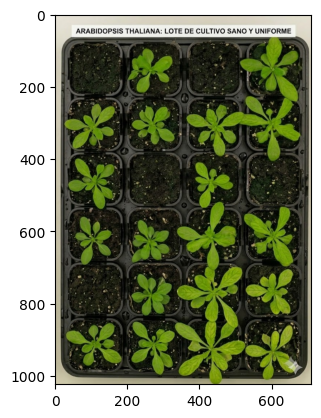

In [77]:
img, path, filename = pcv.readimage(filename=args.image1)

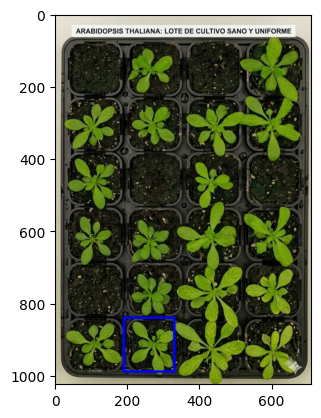

In [78]:
crop_img = pcv.crop(img=img, x=190, y=840, h=150, w=140)

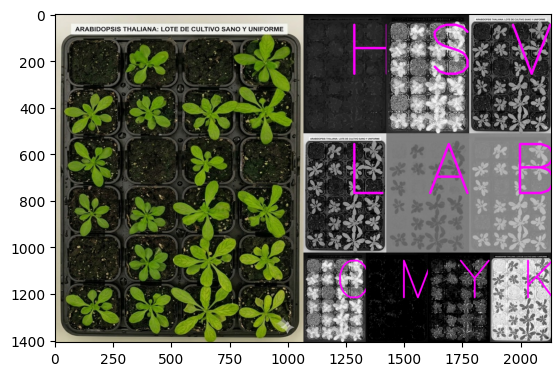

In [79]:
colorspace_img = pcv.visualize.colorspaces(rgb_img=img)

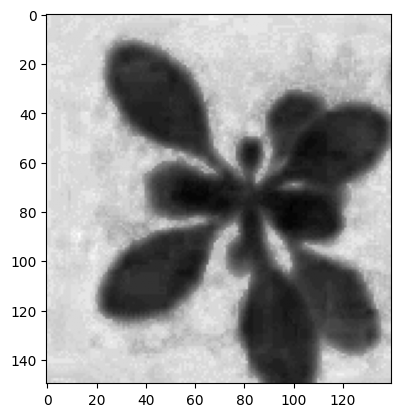

In [80]:
a = pcv.rgb2gray_lab(rgb_img=crop_img, channel='a')

In [81]:
hist_figure1 = pcv.visualize.histogram(a, bins=50)

alt.Chart(...)

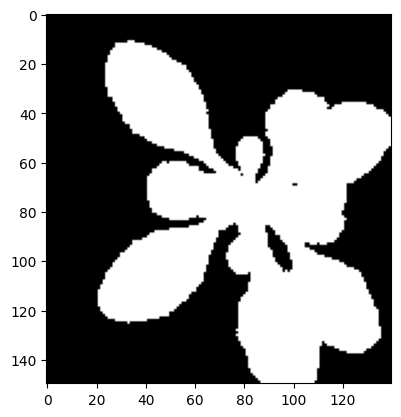

In [82]:
# img_binary = pcv.threshold.binary(gray_img=a, threshold=115, object_type='dark')
img_binary = pcv.threshold.otsu(gray_img=a, object_type='dark')


/home/flan/Documents/programming_proyects/AgenteAgricultura/.venv/lib/python3.13/site-packages/plantcv/plantcv/_helpers.py:899: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  return function(sub_img, **kwargs)


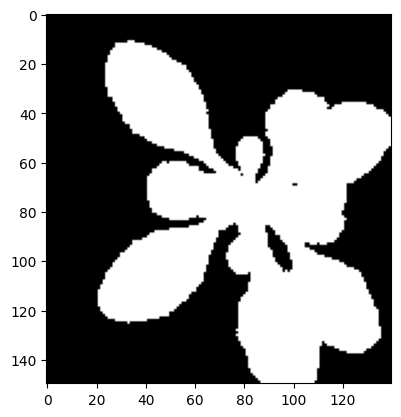

In [83]:
fill_image = pcv.fill(bin_img=img_binary, size=200)

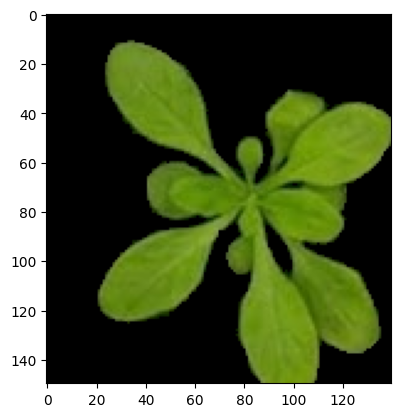

In [84]:
masked = pcv.apply_mask(img=crop_img, mask=fill_image, mask_color="black")

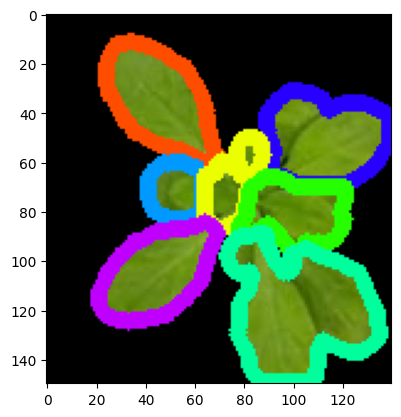

In [85]:
analysis_images = pcv.watershed_segmentation(rgb_img=masked, mask=fill_image, distance=15, label="default")

In [86]:
count=pcv.outputs.observations["default"]["estimated_object_count"]["value"]
print(count)

7
